AIMA-LAB - lezione 1
- Algoritmi di ricerca nello spazio degli stati
- Problema delle città della Romania

In [1]:
# ATTENZIONE: eseguire questo blocco solo se si sta usando Google Colab. Se si lavora in locale basta estrarre in questa cartella la libreria aima.zip caricata su Unistudium
import sys, os

py_file_location = "/content/aima"
sys.path.append(os.path.abspath(py_file_location))

print("Caricare la libreria aima.zip come distribuita nella pagina Unistudium del corso")
from google.colab import files
upload = files.upload()

Caricare la libreria aima.zip come distribuita nella pagina Unistudium del corso


Saving aima.zip to aima.zip


In [2]:
# Estrai la libreria aima. Usare solo da Google Colab o se il comando unzip è installato
!unzip aima.zip

Archive:  aima.zip
   creating: aima/
  inflating: aima/search.py          
  inflating: aima/utils.py           
 extracting: aima/__init__.py        


In [3]:
# Installa le dipendenze nell'ambiente locale
%pip install numpy

In [4]:
from aima import Problem, Node, PriorityQueue, GraphProblem, memoize, romania_map
from collections.abc import Callable
from collections import deque
import time, sys

# Colori da usare nella print()
BLUE = "\033[34;1m"
RED = "\033[31;1m"
GREEN = "\033[32;1m"
RESET = "\033[0m"

In [5]:
# Funzione per eseguire gli algoritmi e stampare alcune informazioni come
# risultato, costi della soluzione e tempo di esecuzione.
def execute(name: str, algorithm: Callable, problem: Problem, *args) -> None:
    print(f"{RED}{name}{RESET}\n")
    start = time.time()
    sol = algorithm(problem, *args)
    end = time.time()
    print(f"\n{GREEN}PROBLEM:{RESET} {problem.initial} -> {problem.goal}")
    print(f"{GREEN}Result:{RESET} {sol.solution() if sol is not None else '---'}")
    if isinstance(sol, Node):
        print(f"{GREEN}Path Cost:{RESET} {sol.path_cost}")
        print(f"{GREEN}Path Length:{RESET} {sol.depth}")
    print(f"{GREEN}Time:{RESET} {end - start} s")

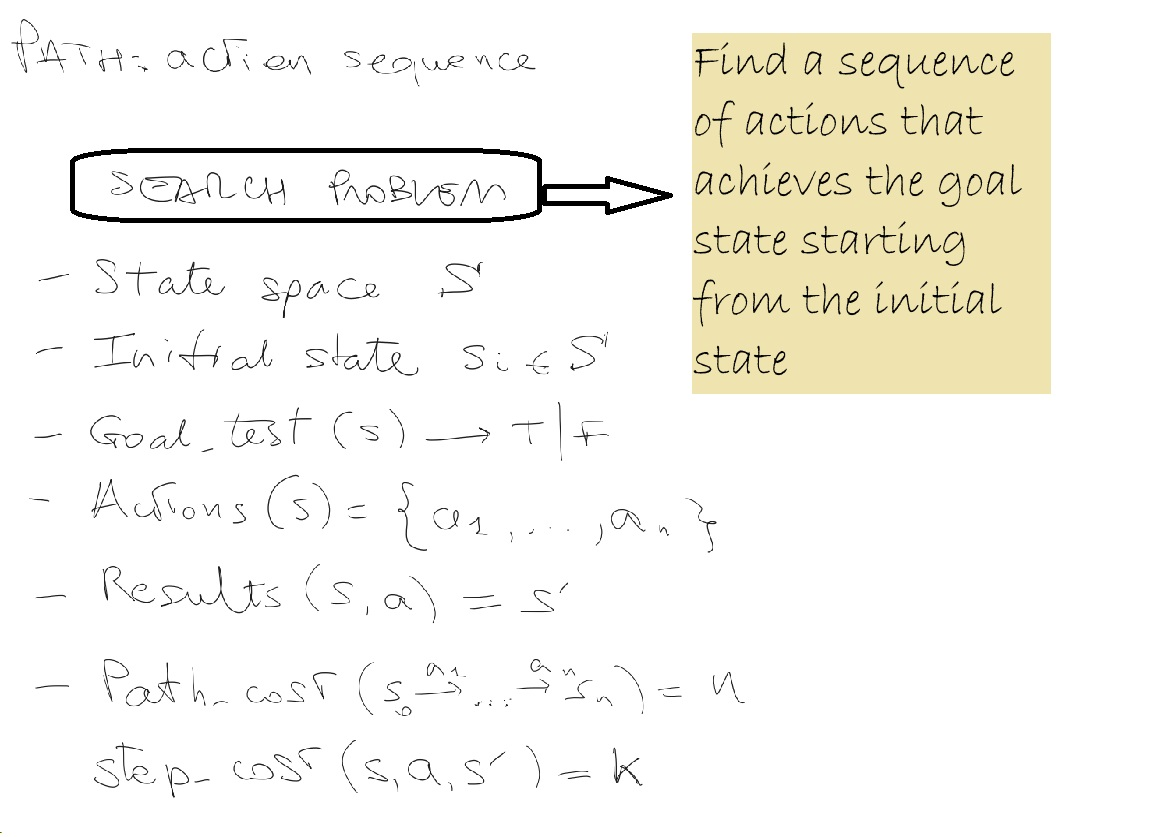

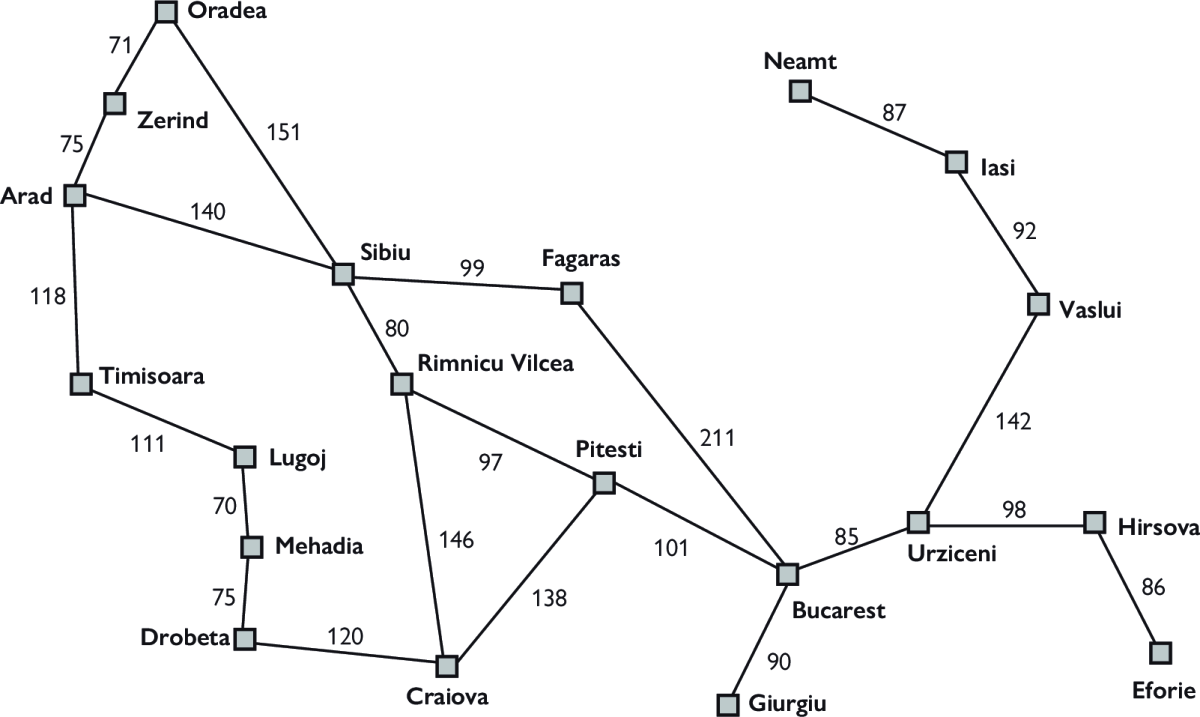

In [6]:
#BFS su grafo
def breadth_search_graph(problem: Problem) -> Node:
  #inizializzazione
  node = Node(problem.initial)
  if problem.goal_test(node.state):
    return node
  frontier = deque([node])
  explored = set()
  print("Frontier BFS:")
  #scorrimento frontiera
  while frontier:
    #estrazione del nodo da deque
    node = frontier.popleft()
    explored.add(node.state)
    #analisi dei figli
    for child in node.expand(problem):
      #se non l'ho già esplorato e non è già in frontiera
      if child.state not in explored and child not in frontier:
        # verifica anticipata del goal
        if problem.goal_test(child.state):
          print("Last Expanded:", node)
          print("Explored node in BFS:", len(explored))
          return child
        # altrimenti lo metto in frontiera
        frontier.append(child)
        print(f"Added: {child}")
  return None

In [ ]:
# DFS su grafo
def depth_search_graph(problem: Problem) -> Node:
  # inizializzazione
  node = Node(problem.initial)
  frontier = [node]
  explored = set()
  print("Frontier DFS:")
  # scorrimento frontiera
  while frontier:
    #estrazione del nodo dalla lista (ultimo)
    node = frontier.pop()
    #verifica del goal
    if problem.goal_test(node.state):
        print("Last Expanded:", node)
        print("Explored nodes in DFS:", len(explored))
        return node
    # inserimento fra gli esplorati
    explored.add(node.state)
    # analisi dei figli
    for child in node.expand(problem):
      #se non l'ho già esplorato e non è già in frontiera
      if child.state not in explored and child not in frontier:
        # lo metto in frontiera per essere estratto al prossimo step
        frontier.append(child)
        print(f"Added: {child}")
  return None

In [ ]:
# BestFirst su grafo
def best_first_search_graph(problem: Problem, f: Callable) -> Node:
    node: Node = Node(problem.initial)
    if problem.goal_test(node.state):
        return node
    f = memoize(f, 'f')
    # This means that the f values will be cached on the nodes as they are computed.
    # So after doing a best first search you can examine the f values of the path returned.
    # Function implementation at row 408 in utils.py
    frontier = PriorityQueue('min', f)
    frontier.append(node)
    explored = set()
    print("Frontier Best-First:")
    while frontier:
        node = frontier.pop()
        if problem.goal_test(node.state):
            print(f"Last Expanded: {node} with f={node.f}")
            print("Explored nodes:", len(explored))
            return node
        explored.add(node.state)
        for child in node.expand(problem):
            if child.state not in explored and child not in frontier:
                frontier.append(child)
                print(f"Added: {child} with f={child.f}{f', h={child.h}' if hasattr(child, 'h') else ''} and g={child.path_cost}")
            elif child in frontier:
                inc = frontier.get_item(child)
                if f(child) < f(inc):
                    del frontier[inc]
                    frontier.append(child)
                    print(f"({inc}, {inc.f}) -- replaced by ({child}, {child.f})")
    return None

In [ ]:
# Varianti della BestFirst utilizzando diverse funzioni di costo
def ucs(problem: Problem) -> Node:
  return best_first_search_graph(problem, lambda node : node.path_cost)

def greedy(problem: Problem, h: Callable | Node = None) -> Node:
  h = memoize(h or problem.h, 'h')
  return best_first_search_graph(problem, lambda node : h(node))

def astar(problem: Problem, h: Callable | Node = None) -> Node:
  h = memoize(h or problem.h, 'h')
  return best_first_search_graph(problem, lambda node : h(node) + node.path_cost)

In [ ]:
# Depth-Limited search
def there_is_cycle(node: Node, k: int = 10) -> bool:
  def find_cycle(ancestor: Node, k: int):
    return ancestor is not None and k > 0 and (ancestor.state == node.state or find_cycle(ancestor.parent, k-1))
  return find_cycle(node.parent, k)

def depth_lim_search(problem: Problem, lvl: int) -> Node | str:
    frontier = [Node(problem.initial)]
    solution = 'failure'
    print("Frontier Depth-Limit:")
    while frontier:
        node = frontier.pop()
        print(f"Pop node: {node}")
        if problem.goal_test(node.state):
            print(f"{node} is the goal!")
            return node
        elif node.depth > lvl:
            solution = 'cutoff'
            print("LIMIT REACHED: cutoff")
        elif not there_is_cycle(node):
            for child in node.expand(problem):
                frontier.append(child)
                print(f"Added: {child}")
    return solution

In [ ]:
# IDS
def ids(problem: Problem) -> Node | str:
  for limit in range(1, sys.maxsize):
    print("LIMIT =", limit)
    result = depth_lim_search(problem, limit)
    if result != 'cutoff':
        return result

In [ ]:
# DFS e BFS su albero

def breadth_search_tree(problem: Problem) -> Node | None:
    # N.B possibili loop infiniti
    frontier = deque([Node(problem.initial)])  # FIFO queue
    while frontier:
        node = frontier.popleft()
        if problem.goal_test(node.state):
            return node
        frontier.extend(node.expand(problem))
    return None

def depth_search_tree(problem: Problem) -> Node | None:
    #  N.B possibili loop infiniti!
    frontier = [Node(problem.initial)]  # LIFO stack
    while frontier:
        node = frontier.pop()
        if problem.goal_test(node.state):
            return node
        frontier.extend(node.expand(problem))
    return None

Esempio di applicazione degli algoritmi (Mappa delle città della Romania)

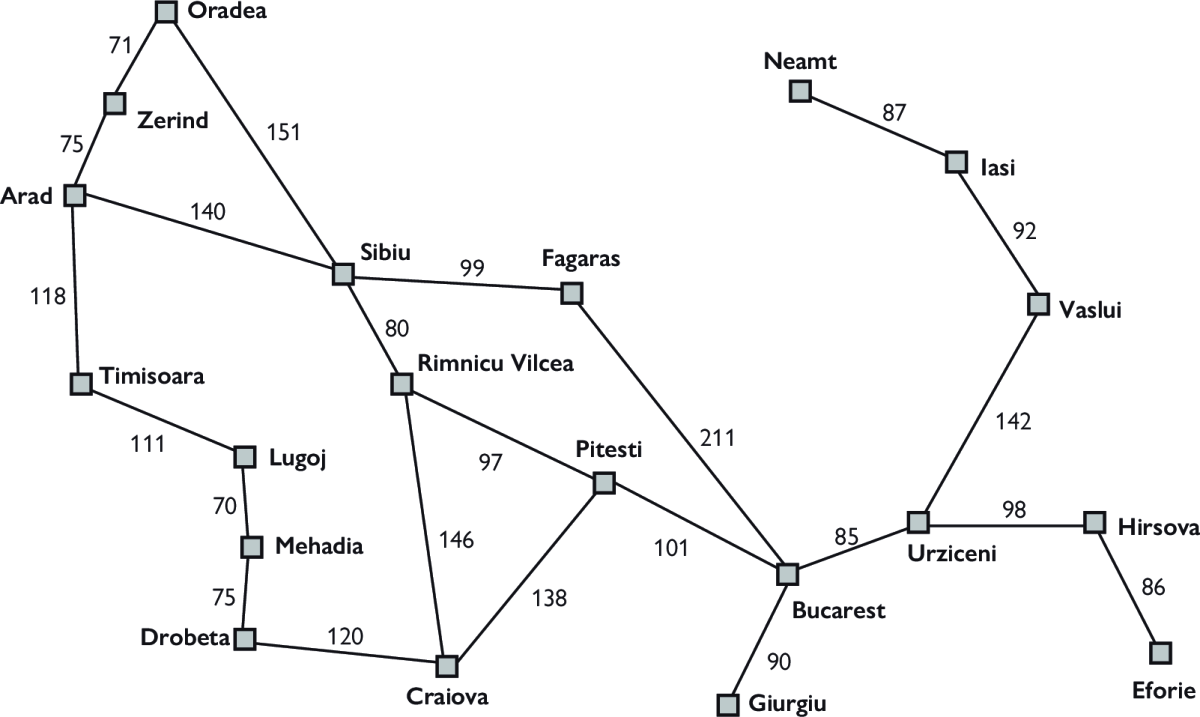

In [ ]:
romania_problem = GraphProblem('Arad','Bucharest', romania_map)

# ALTRI PROBLEMI: inserire dopo e fare prove
romania_problem2 = GraphProblem('Lugoj', 'Zerind', romania_map) # DFS molto lunga e BFS = UC
romania_problem3 = GraphProblem('Lugoj', 'Craiova', romania_map) #  Tutti e 3 uguali
romania_problem4 = GraphProblem('Lugoj', 'Neamt', romania_map) # cammino lungo DFS = UC != BFS

In [ ]:
execute("BFS su grafo", breadth_search_graph, romania_problem)

In [ ]:
execute("DFS su grafo", depth_search_graph, romania_problem)

In [ ]:
execute("UCS su grafo", ucs, romania_problem)

In [ ]:
execute("Greedy su grafo", greedy, romania_problem)

In [ ]:
execute("A* su grafo", astar, romania_problem)

In [ ]:
execute("DepthLimit su grafo", depth_lim_search, romania_problem, 10)

In [ ]:
execute("IDS su grafo", ucs, romania_problem)